            FAST-FOOD DRIVE-THRU SIMULATION REPORT
Total Simulation Time: 60 minutes
------------------------------------------------------------
STATION PERFORMANCE (Average Queue Length):
 -> Order Station  : 0.58 cars waiting
 -> Payment Window : 0.49 cars waiting
 -> Pick-up Window : 3.11 cars waiting
------------------------------------------------------------
SYSTEM BOTTLENECK IDENTIFIED: [ PICK-UP WINDOW ] ⚠️


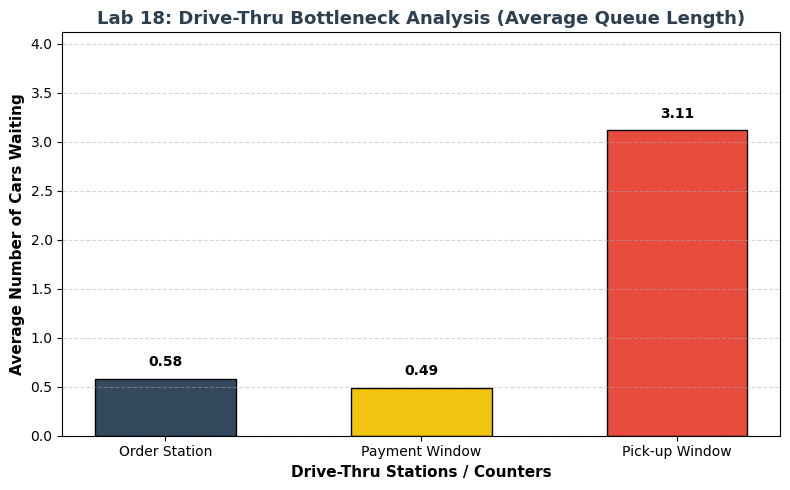

In [6]:
import random
import simpy
import matplotlib.pyplot as plt

# --- ১. প্যারামিটার ও কনফিগুরেশন সেটআপ ---
RANDOM_SEED = 42
SIM_TIME = 60          # ৬০ মিনিট বা ১ ঘণ্টার সিমুলেশন
ARRIVAL_RATE = 2.0     # গড়ে প্রতি ২ মিনিটে ১টি গাড়ি আসবে

# ৩টি কাউন্টারের গড় সার্ভিস টাইম (মিনিটে)
TIME_ORDER = 1.0       # অর্ডারে লাগবে ১ মিনিট
TIME_PAY = 1.2         # পেমেন্টে লাগবে ১.২ মিনিট
TIME_PICKUP = 3.0      # পিক-আপে লাগবে ৩ মিনিট (বোটলনেক দেখানোর জন্য এটি বড় রাখা হয়েছে)

# ডাটা ট্র্যাকিংয়ের জন্য ভ্যারিয়েবল
stations = ['Order Station', 'Payment Window', 'Pick-up Window']
queue_counts = {s: 0 for s in stations}
time_log = []
queue_logs = {s: [] for s in stations}

def drive_thru_car(env, name, order_st, pay_win, pickup_win):
    global queue_counts
    
    # --- ক. অর্ডার কাউন্টার ---
    queue_counts['Order Station'] += 1
    time_log.append(env.now)
    for s in stations: queue_logs[s].append(queue_counts[s])
    
    with order_st.request() as req:
        yield req
        queue_counts['Order Station'] -= 1
        yield env.timeout(random.expovariate(1.0 / TIME_ORDER))
        
    # --- খ. পেমেন্ট কাউন্টার ---
    queue_counts['Payment Window'] += 1
    time_log.append(env.now)
    for s in stations: queue_logs[s].append(queue_counts[s])
    
    with pay_win.request() as req:
        yield req
        queue_counts['Payment Window'] -= 1
        yield env.timeout(random.expovariate(1.0 / TIME_PAY))
        
    # --- গ. পিক-আপ কাউন্টার ---
    queue_counts['Pick-up Window'] += 1
    time_log.append(env.now)
    for s in stations: queue_logs[s].append(queue_counts[s])
    
    with pickup_win.request() as req:
        yield req
        queue_counts['Pick-up Window'] -= 1
        yield env.timeout(random.expovariate(1.0 / TIME_PICKUP))
        
    # গাড়ি বিদায় নেওয়ার পর লগ আপডেট
    time_log.append(env.now)
    for s in stations: queue_logs[s].append(queue_counts[s])

def car_generator(env, order_st, pay_win, pickup_win):
    car_id = 1
    while True:
        yield env.timeout(random.expovariate(1.0 / ARRIVAL_RATE))
        env.process(drive_thru_car(env, f"Car {car_id}", order_st, pay_win, pickup_win))
        car_id += 1

# --- ২. সিমুলেশন এনভায়রনমেন্ট ও রান ---
random.seed(RANDOM_SEED)
env = simpy.Environment()

order_st = simpy.Resource(env, capacity=1)
pay_win = simpy.Resource(env, capacity=1)
pickup_win = simpy.Resource(env, capacity=1)

env.process(car_generator(env, order_st, pay_win, pickup_win))
env.run(until=SIM_TIME)

# সিমুলেশনের ডেটা থেকে প্রতিটি কাউন্টারের গড় কিউ লেন্থ বের করা
avg_queues = [sum(queue_logs[s])/len(queue_logs[s]) for s in stations]

# --- ৩. টেক্সট রিপোর্ট প্রিন্ট ---
print("=" * 60)
print("            FAST-FOOD DRIVE-THRU SIMULATION REPORT")
print("=" * 60)
print(f"Total Simulation Time: {SIM_TIME} minutes")
print("-" * 60)
print("STATION PERFORMANCE (Average Queue Length):")
for s, q_val in zip(stations, avg_queues):
    print(f" -> {s:<15}: {q_val:.2f} cars waiting")
print("-" * 60)

# সর্বোচ্চ কিউ লেন্থের ওপর ভিত্তি করে বোটলনেক নির্ধারণ
bottleneck_idx = avg_queues.index(max(avg_queues))
print(f"SYSTEM BOTTLENECK IDENTIFIED: [ {stations[bottleneck_idx].upper()} ] ⚠️")
print("=" * 60)

# --- ৪. বার চার্ট গ্রাফ প্রদর্শন (Bottleneck Bar Chart) ---
plt.figure(figsize=(8, 5))
bar_colors = ['#34495e', '#f1c40f', '#e74c3c']  # ৩টি কাউন্টারের জন্য ৩টি আলাদা রঙ

# বার চার্ট তৈরি করা
bars = plt.bar(stations, avg_queues, color=bar_colors, edgecolor='black', width=0.55)

# প্রতিটা বারের মাথার ওপর তার নির্দিষ্ট সংখ্যাটি নিখুঁতভাবে বসানোর লুপ
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

# গ্রাফের লেবেল ও টাইটেল সেটআপ
plt.title("Lab 18: Drive-Thru Bottleneck Analysis (Average Queue Length)", fontsize=13, fontweight='bold', color='#2c3e50')
plt.xlabel("Drive-Thru Stations / Counters", fontsize=11, fontweight='bold')
plt.ylabel("Average Number of Cars Waiting", fontsize=11, fontweight='bold')
plt.ylim(0, max(avg_queues) + 1.0)  # গ্রাফের ওপরে কিছুটা ফাঁকা জায়গা রাখার জন্য
plt.grid(axis='y', linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()